### Task 1 — Data Loading & Exploration

In [3]:
import pandas as pd 
import numpy as np

In [4]:
# Load the CSV file using Pandas
df = pd.read_csv("Housing.csv")
df 

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [5]:
#  Display the first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [6]:
#  Check how many rows and columns are there
df.shape

(545, 13)

In [7]:
#  Identify which column is the target (Price) and which are features
target = "price"
features = df.drop(columns=[target]).columns
print("Target:", target)
print("Features:", features)

Target: price
Features: Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [8]:
# Check for missing values in each column
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Task 2 — Data Cleaning
 

In [9]:
df_clean = df.copy()


num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# Handle missing values (fill or drop, whichever fits the column)

for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Filled missing values in '{col}' with median = {median_val}")

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"Filled missing values in '{col}' with mode = '{mode_val}'")

print("\nRemaining missing values:", df_clean.isnull().sum().sum())


Numeric columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Remaining missing values: 0


In [10]:
# Remove duplicate rows
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Duplicate rows: 0
After removing duplicates: (545, 13)


In [11]:
# Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding

df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,True,False,True,False,False,False,False,True
541,1767150,2400,3,1,1,0,False,False,False,False,False,False,True,False
542,1750000,3620,2,1,1,0,True,False,False,False,False,False,False,True
543,1750000,2910,3,1,1,0,False,False,False,False,False,False,False,False


In [12]:
#  Keep only the columns that are meaningful for predicting price
col_drop = ["stories"]
df.drop(columns=col_drop)

,price,area,bedrooms,bathrooms,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,no,no,no,no,no,0,no,furnished


### Task 3 — Model Building

In [13]:
# Split the data into training and test sets (80/20)
from sklearn.model_selection import train_test_split
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']
# X = df.drop("price", axis=1)
# y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training test :", X_train.shape[0])
print("Test test :", X_test.shape[0])

Training test : 436
Test test : 109


In [14]:
# Train a Linear Regression model to predict house price
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)




Linear Regression Results
MAE : 970043.4039201637
RMSE: 1324506.9600914388
R² Score: 0.6529242642153184


In [15]:
# Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)


Random Forest Results
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [16]:
# Performance Comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


### Task 4 — Visualization (Minimum 3 charts)


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

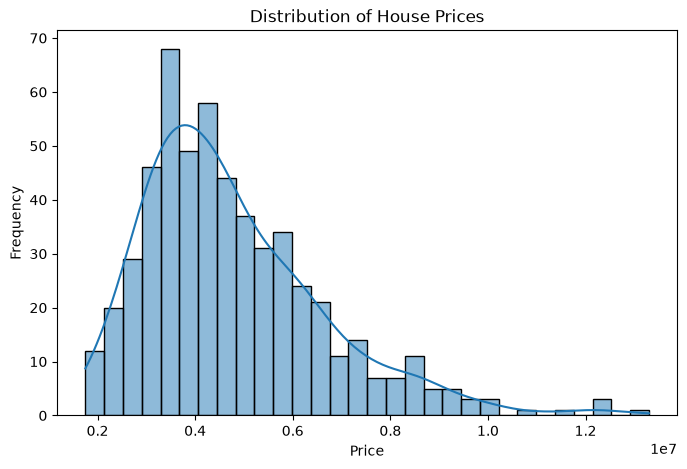

In [28]:
#  Chart 1: Histogram showing the distribution of house prices

plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig('Chart 1.png', dpi=300, bbox_inches='tight')
plt.show()

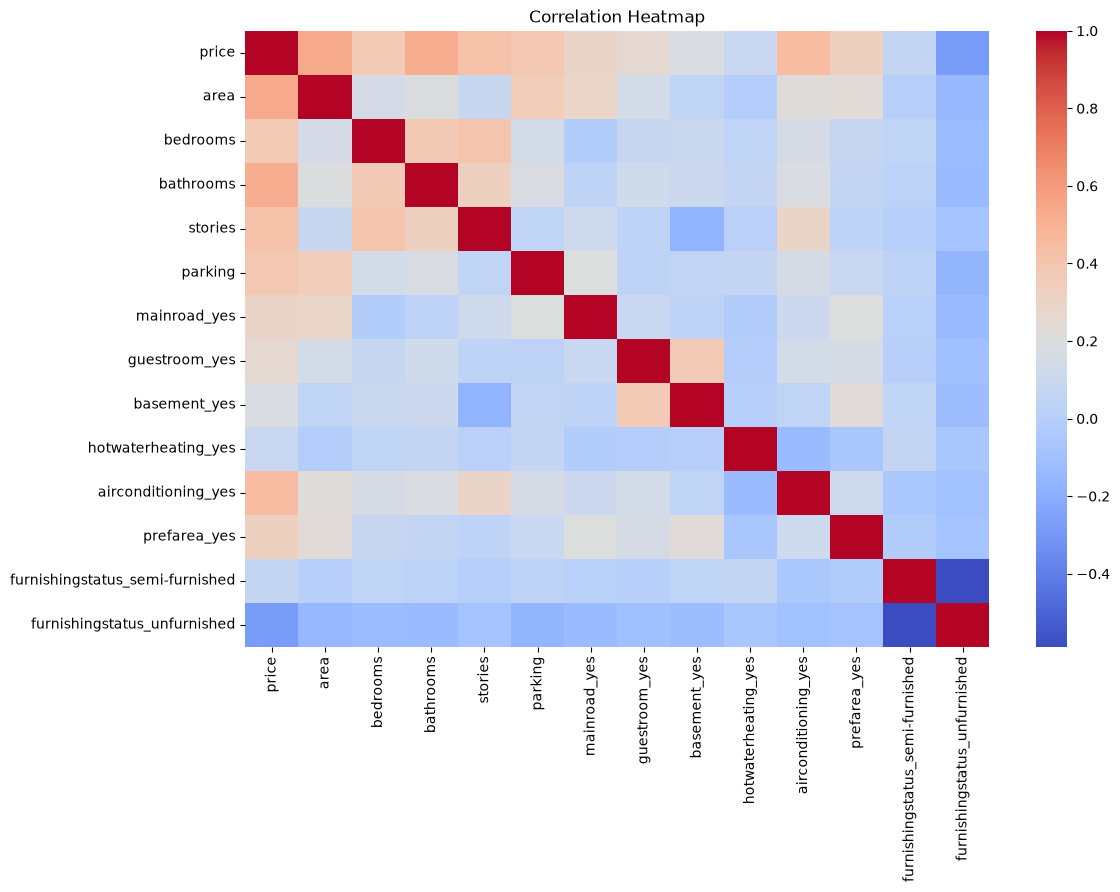

In [29]:
# Chart 2: Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(12,8))

corr = df_encoded.corr()

sns.heatmap(corr,
            cmap='coolwarm',
            annot=False)

plt.title("Correlation Heatmap")
plt.savefig('Chart 2.png', dpi=300, bbox_inches='tight')
plt.show()

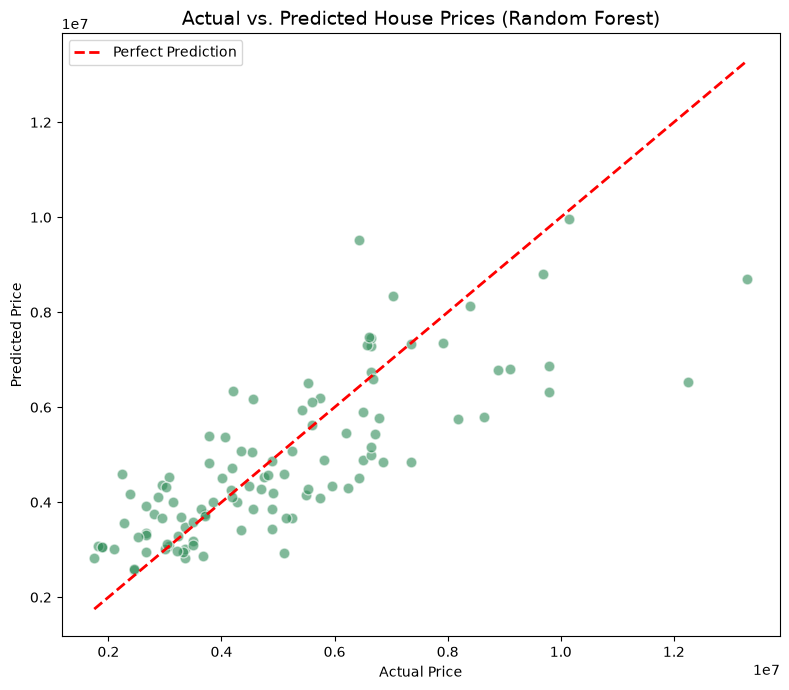

In [30]:
# Chart 3 Actual vs Predicted Price Scatter Plot
plt.figure(figsize=(8, 7))
plt.scatter(y_test, rf_pred, alpha=0.6, color="seagreen", edgecolor="white", s=60)

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted House Prices (Random Forest)", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('Chart 3.png', dpi=300, bbox_inches='tight')
plt.show()

### Task 5 — Insights & Summary

<p>From the analysis, features such as area, number of bathrooms, number of stories, air conditioning, and preferred area had the greatest influence on house prices. Among the two models tested, Linear Regression performed better, achieving an R² score of approximately 0.65, which means the model was able to explain about 65% of the variation in house prices and provided reasonably accurate predictions. It was surprising to observe that amenities like air conditioning and location preference significantly affected prices in addition to the size of the house. Another interesting finding was that increasing the number of bathrooms and stories generally corresponded to higher prices. Based on these results, real estate businesses should focus on properties with larger areas and premium amenities, as these factors contribute substantially to higher property values and customer demand.</p>